In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
## abrir fazer head
## info
## describe (min max meadia desvio padrao quartis desvio padrão)
## correlacioanar dados 
## isnull.sum
#########################
## pre-processamento
## encode 
##drop
##fill
## scale
##over/under sampling 
###########################
## treinar com os modelos dadas nas aulas 


In [31]:
df=pd.read_csv('datasets/stroke-data.csv')


In [32]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [34]:
df['stroke'].value_counts() ## quantos tiveram AVC e quantos nao tiveram AVC

stroke
0    4861
1     249
Name: count, dtype: int64

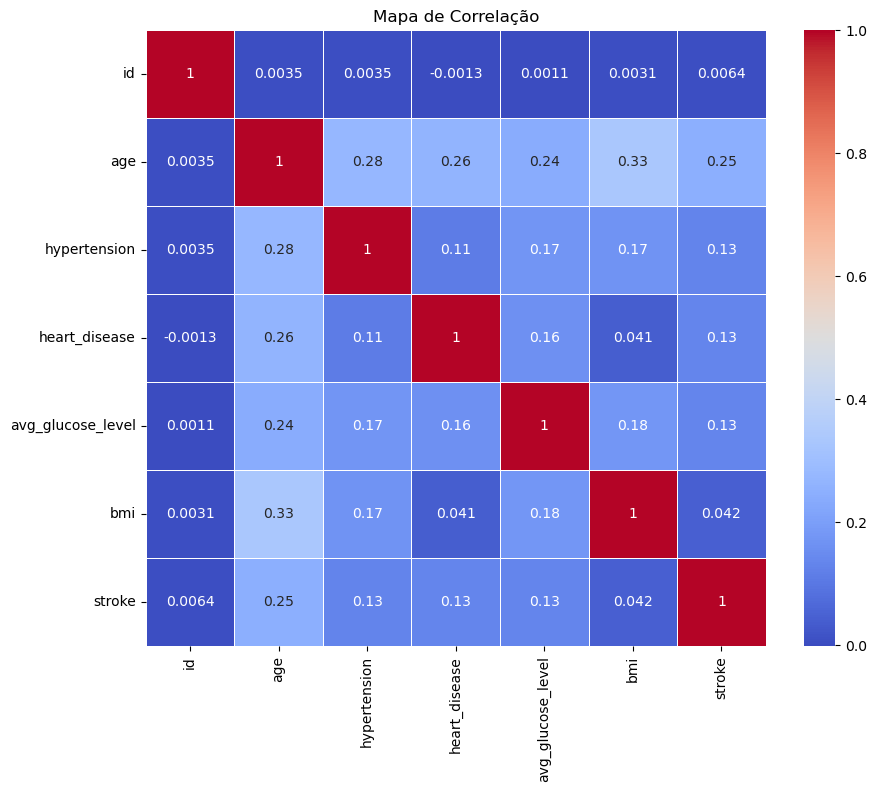

In [35]:
## Analise da correlação entre as variáveis

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm',linewidths=0.5)
plt.title('Mapa de Correlação')
plt.show()


In [36]:
df.isnull().sum() ## verificar se há valores nulos

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [37]:
## BMI e Stroke nao tem grande correlação entao nao precisamos de dar grande atenção a estes valores em falta

In [38]:
## eliminar coluna bmi

df.drop('bmi', axis=1, inplace=True)

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type']:
    df[col] = le.fit_transform(df[col])
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,formerly smoked,1
1,51676,0,61.0,0,0,1,3,0,202.21,never smoked,1
2,31112,1,80.0,0,1,1,2,0,105.92,never smoked,1
3,60182,0,49.0,0,0,1,2,1,171.23,smokes,1
4,1665,0,79.0,1,0,1,3,0,174.12,never smoked,1


In [53]:
## por a coluna smoking_status em one-hot encoding
df = pd.get_dummies(df, columns=['smoking_status'], drop_first=True)
df.head()

KeyError: "None of [Index(['smoking_status'], dtype='object')] are in the [columns]"

In [50]:
## treinara um modelo de machine learning para prever se um paciente terá um AVC ou não, usando as variáveis disponíveis no dataset.

from sklearn.model_selection import train_test_split
X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

[[960   0]
 [ 62   0]]


/Users/utilizador/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/utilizador/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/utilizador/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

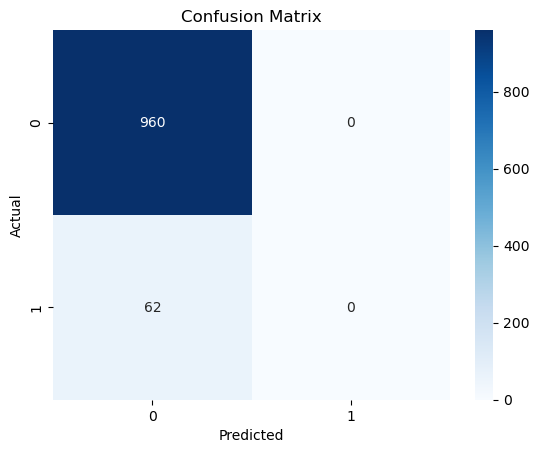

In [51]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()